# SFANC-FxNLMS 主动噪声控制算法

## 算法概述
本笔记本演示了选择性固定滤波器主动噪声控制（SFANC）与滤波-x归一化最小均方（FxNLMS）算法的混合实现。该算法结合了预训练控制滤波器的稳定性和FxNLMS算法的自适应能力，用于实时噪声控制。

In [9]:
# 导入必要的库
import matplotlib.pyplot as plt  # 绘图库
import numpy as np  # 数值计算库
import torch  # 深度学习框架
from scipy.io import savemat  # MATLAB文件读写
import math  # 数学函数

# 导入自定义模块
from data.loading_real_wave_noise import loading_real_wave_noise  # 加载真实噪声数据
from Reading_path_test import loading_paths_from_MAT  # 从MAT文件加载路径
from algorithm.Control_filter_selection import Control_filter_selection  # 控制滤波器选择
from algorithm.FxNLMS_algorithm import FxNLMS, train_fxnlms_algorithm  # FxNLMS算法
from data.Disturbance_generation import Disturbance_generation_from_real_noise  # 从真实噪声生成干扰信号
from algorithm.Combine_SFANC_with_FxNLMS import SFANC_FxNLMS  # SFANC-FxNLMS混合算法

# 检查GPU是否可用
print('GPU可用性:', torch.cuda.is_available())

GPU可用性: False


## 数据加载与预处理

加载真实噪声数据并进行预处理，为后续算法训练做准备。

In [10]:
# 加载真实噪声数据
fs = 16000  # 采样率：16kHz
StepSize = 0.0001  # FxNLMS算法的学习率
sound_name = 'Traffic'  # 噪声类型：交通噪声

# 从WAV文件加载噪声波形数据
waveform, resample_rate = loading_real_wave_noise(
    folde_name='Real Noise Examples/',  # 噪声文件所在目录
    sound_name=sound_name+'.wav'  # 噪声文件名
)

In [11]:
# 加载主路径和次级路径
Pri_path, Secon_path = loading_paths_from_MAT(
    folder='Primary and Secondary Path',  # 路径文件所在主目录
    subfolder='',  # 子目录
    Pri_path_file_name='Primary_path.mat',  # 主路径文件名
    Sec_path_file_name='Secondary_path.mat'  # 次级路径文件名
)

# 从真实噪声生成干扰信号
# Dis: 干扰信号（受控噪声）
# Fx: filtered-x信号
# Re: 重复波形（主噪声）
Dis, Fx, Re = Disturbance_generation_from_real_noise(
    fs=fs,  # 采样率
    Repet=0,  # 重复次数
    wave_form=waveform,  # 输入波形
    Pri_path=Pri_path,  # 主路径
    Sec_path=Secon_path  # 次级路径
)

In [12]:
# 打印数据形状，验证数据加载正确性
print('原始波形形状:', waveform.shape)
print('重复波形形状:', Re.shape)
print('干扰信号形状:', Dis.shape)

# 设置matplotlib参数，处理大数据集绘图
import matplotlib as mpl
mpl.rcParams['agg.path.chunksize'] = 10000  # 增加路径块大小以避免绘图错误

原始波形形状: torch.Size([1, 211107])
重复波形形状: torch.Size([211107])
干扰信号形状: torch.Size([208000])


## FxNLMS 算法实现

实现标准的滤波-x归一化最小均方算法，作为基准对比。

[========================================================================] 100%


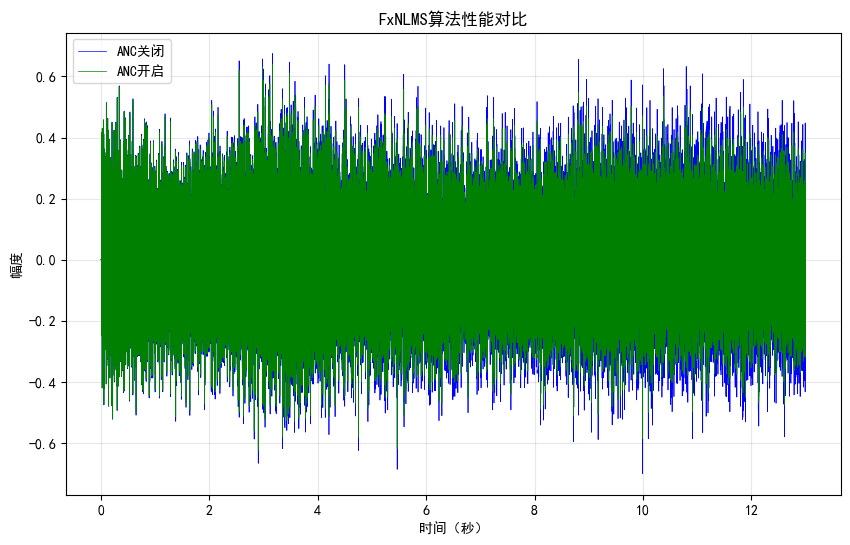

In [13]:
# FxNLMS算法训练

# 初始化FxNLMS控制器，滤波器长度为1024
# 1024与固定滤波器的系数向量长度相同
controller = FxNLMS(Len=1024)

# 训练FxNLMS算法
ErrorFxNLMS = train_fxnlms_algorithm(
    Model=controller,  # FxNLMS模型
    Ref=Fx,  # 参考信号（filtered-x信号）
    Disturbance=Dis,  # 干扰信号
    Stepsize=StepSize  # 学习率
)

# 创建时间轴用于绘图
Time = np.arange(len(Dis)) / fs

# 绘制FxNLMS算法结果
plt.figure(figsize=(10, 6))
plt.title('FxNLMS算法性能对比')
plt.plot(Time, Dis, color='blue', label='ANC关闭', linewidth=0.5)
plt.plot(Time, ErrorFxNLMS, color='green', label='ANC开启', linewidth=0.5)
plt.ylabel('幅度')
plt.xlabel('时间（秒）')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('pdf/FxNLMS.pdf', dpi=600, bbox_inches='tight', pad_inches=0)
plt.show()

## SFANC-FxNLMS 混合算法

结合选择性固定滤波器（SFANC）和FxNLMS算法的混合实现，利用预训练滤波器的稳定性和自适应算法的灵活性。

In [14]:
# 控制滤波器选择

# 使用CNN模型预测最适合当前噪声的控制滤波器索引
# Primary_noise: 主噪声，形状为torch.Size([1, 采样点数])
id_vector = Control_filter_selection(
    fs=16000,  # 采样率
    Primary_noise=Re.unsqueeze(0)  # 主噪声，增加批次维度
)

print('选择的控制滤波器索引:', id_vector)

选择的控制滤波器索引: [3, 3, 0, 0, 3, 0, 3, 3, 3, 3, 0, 3, 3]


加载了 15 个固定控制滤波器，每个长度 1024


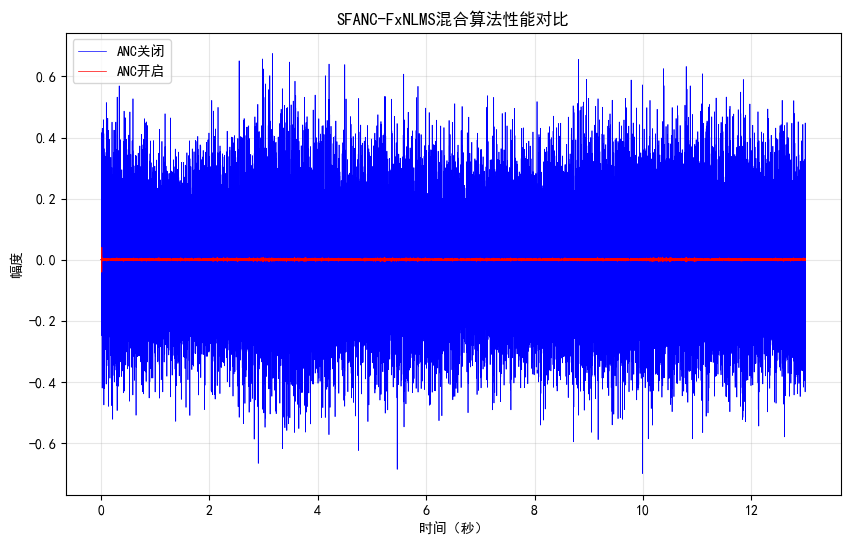

In [15]:
# SFANC-FxNLMS混合算法实现

# 预训练控制滤波器文件路径
FILE_NAME_PATH = 'Trained models/Pretrained_Control_filters.mat'

# 创建SFANC-FxNLMS混合算法实例
SFANC_FxNLMS_Cancellation = SFANC_FxNLMS(
    MAT_FILE=FILE_NAME_PATH,  # 预训练滤波器文件
    fs=16000  # 采样率
)
Dis_np = Dis.numpy().flatten().astype(np.float64)
Fx_np  = Fx.numpy().flatten().astype(np.float64)
# 执行噪声消除
Error_SFANC_FxNLMS = SFANC_FxNLMS_Cancellation.noise_cancellation(
    Dis=Dis_np,  # 干扰信号
    Fx=Fx_np,  # filtered-x信号
    filter_index=id_vector,  # 选择的滤波器索引
    Stepsize=StepSize  # 学习率
)

# 中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
# 绘制混合算法结果
plt.figure(figsize=(10, 6))
plt.title('SFANC-FxNLMS混合算法性能对比')
plt.plot(Time, Dis, color='blue', label='ANC关闭', linewidth=0.5)
plt.plot(Time, Error_SFANC_FxNLMS, color='red', label='ANC开启', linewidth=0.5)
plt.ylabel('幅度')
plt.xlabel('时间（秒）')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('pdf/SFANC_FxNLMS.pdf', dpi=600, bbox_inches='tight', pad_inches=0)
plt.show()

## 性能对比分析

比较FxNLMS算法和SFANC-FxNLMS混合算法的性能差异。

=== 性能对比结果 ===
原始信号RMSE: 0.1604
FxNLMS算法RMSE: 0.1437
混合算法RMSE: 0.0018
FxNLMS SNR改善: 0.96 dB
混合算法SNR改善: 38.92 dB


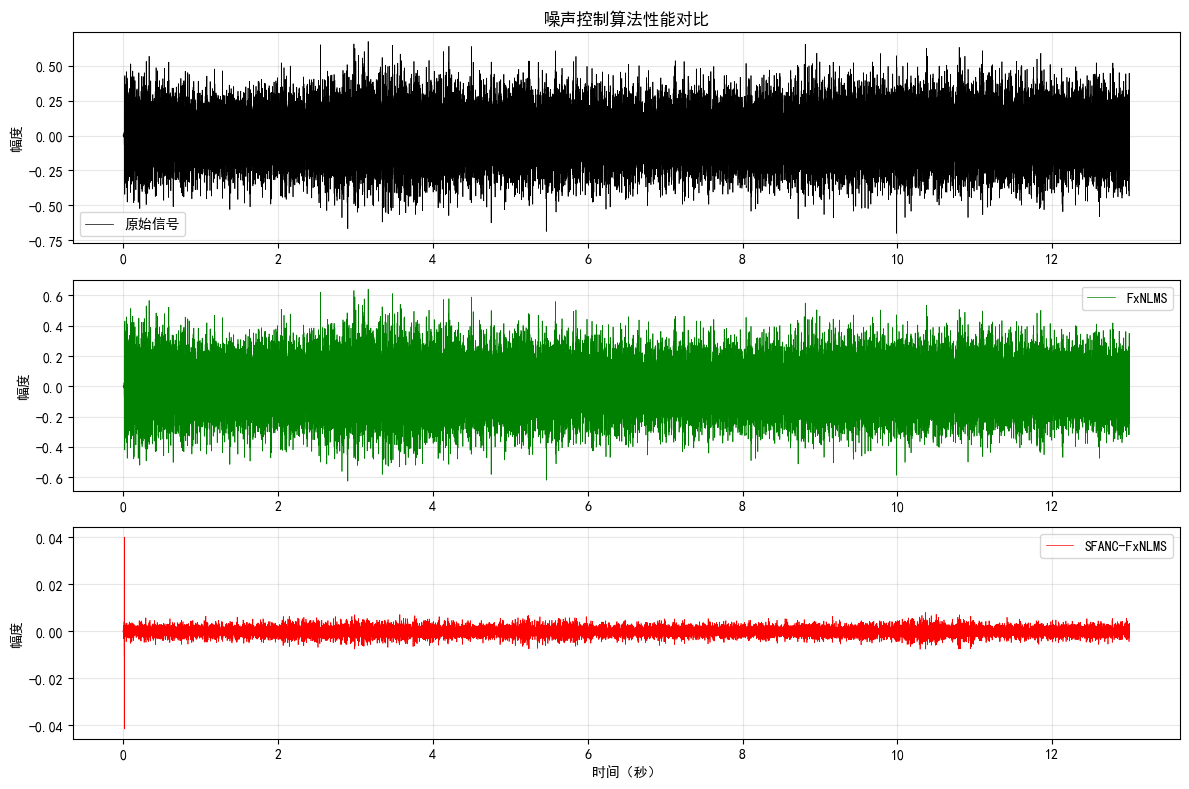

In [16]:
# 性能对比分析

# 确保数据为 numpy 数组（处理列表输入）
ErrorFxNLMS = np.array(ErrorFxNLMS)
Error_SFANC_FxNLMS = np.array(Error_SFANC_FxNLMS)

# 计算均方根误差（RMSE）
rmse_fxnlms = np.sqrt(np.mean(ErrorFxNLMS**2))
rmse_hybrid = np.sqrt(np.mean(Error_SFANC_FxNLMS**2))
Dis = np.asarray(Dis)  # Dis 也统一转为数组，避免后续 var 计算报错

# 计算信噪比改善（SNR Improvement）
snr_original = 10 * np.log10(np.var(Dis) / np.var(Dis))  # 原始SNR
snr_fxnlms = 10 * np.log10(np.var(Dis) / np.var(ErrorFxNLMS))
snr_hybrid = 10 * np.log10(np.var(Dis) / np.var(Error_SFANC_FxNLMS))

print('=== 性能对比结果 ===')
print(f'原始信号RMSE: {np.sqrt(np.mean(Dis**2)):.4f}')
print(f'FxNLMS算法RMSE: {rmse_fxnlms:.4f}')
print(f'混合算法RMSE: {rmse_hybrid:.4f}')
print(f'FxNLMS SNR改善: {snr_fxnlms:.2f} dB')
print(f'混合算法SNR改善: {snr_hybrid:.2f} dB')

# 中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示异常

# 绘制三种情况的对比图
plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(Time, Dis, color='black', label='原始信号', linewidth=0.5)
plt.ylabel('幅度')
plt.legend()
plt.grid(alpha=0.3)
plt.title('噪声控制算法性能对比')

plt.subplot(3, 1, 2)
plt.plot(Time, ErrorFxNLMS, color='green', label='FxNLMS', linewidth=0.5)
plt.ylabel('幅度')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(3, 1, 3)
plt.plot(Time, Error_SFANC_FxNLMS, color='red', label='SFANC-FxNLMS', linewidth=0.5)
plt.ylabel('幅度')
plt.xlabel('时间（秒）')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('pdf/Comparison.pdf', dpi=600, bbox_inches='tight', pad_inches=0)
plt.show()